In [2]:
pip install medmnist

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
from medmnist import DermaMNIST

# Descarga automáticamente
train_dataset = DermaMNIST(split='train', download=True)
val_dataset = DermaMNIST(split='val', download=True)
test_dataset = DermaMNIST(split='test', download=True)

print(len(train_dataset))

100%|██████████| 19.7M/19.7M [00:02<00:00, 7.50MB/s]


7007


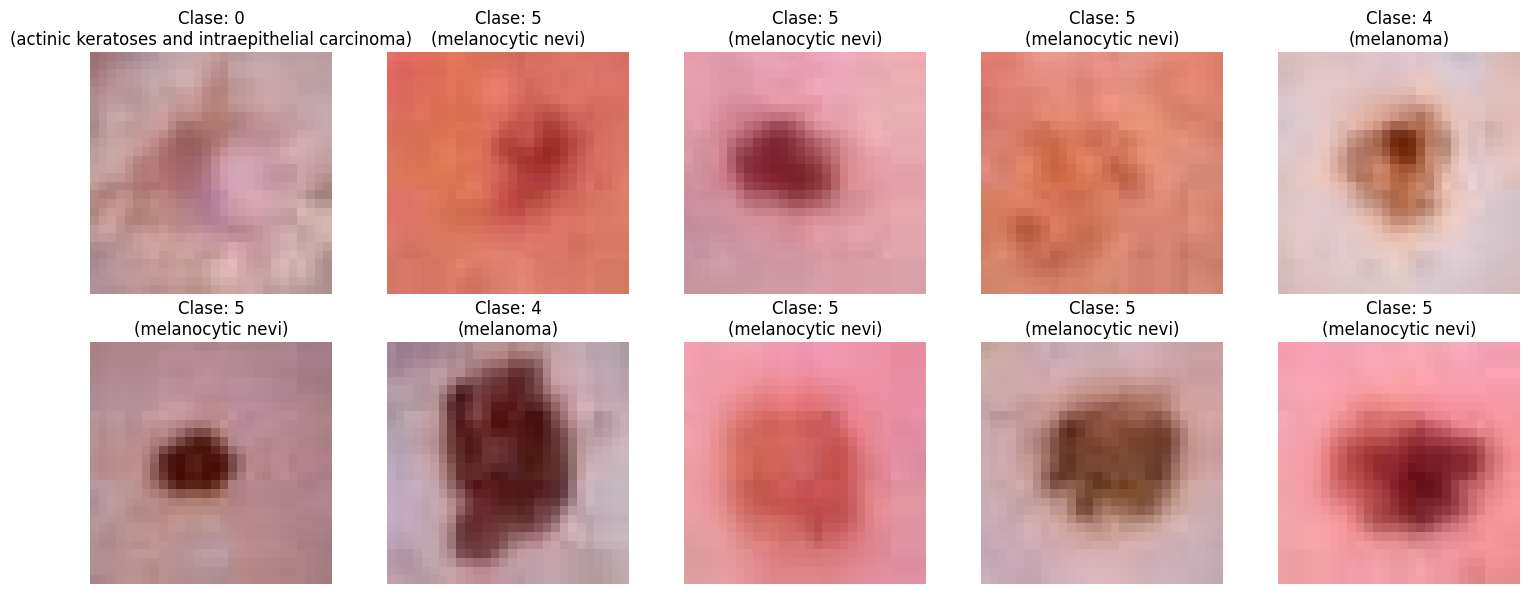

In [4]:
import matplotlib.pyplot as plt

# MedMNIST guarda la metadata del dataset, incluyendo los nombres de las clases
class_dict = train_dataset.info['label']

# Creamos una cuadrícula de 2 filas y 5 columnas
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, ax in enumerate(axes.flatten()):
    # train_dataset[i] devuelve una tupla: (Imagen PIL, Array de la etiqueta)
    img, label = train_dataset[i]
    label_idx = label[0] # Extraemos el número de la etiqueta
    class_name = class_dict[str(label_idx)] # Buscamos el nombre de la enfermedad

    ax.imshow(img)
    ax.set_title(f"Clase: {label_idx}\n({class_name})")
    ax.axis('off')

plt.tight_layout()
plt.show()

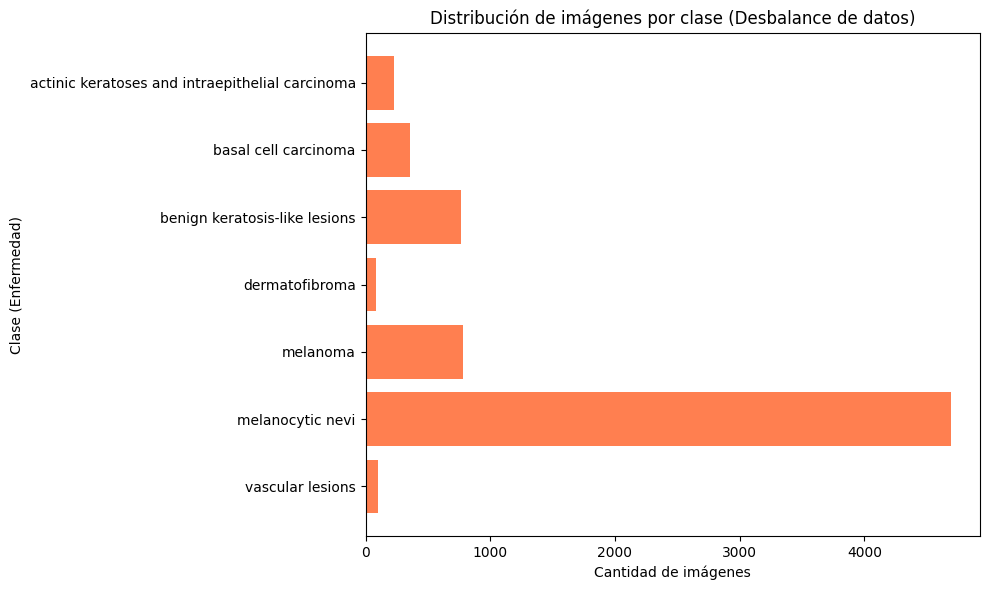

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Aseguramos que class_dict esté definido
class_dict = train_dataset.info['label']

# Extraemos todas las etiquetas del dataset de entrenamiento
labels = [label[0] for img, label in train_dataset]

# Contamos cuántas imágenes hay por clase
clases_unicas, conteos = np.unique(labels, return_counts=True)
nombres_clases = [class_dict[str(c)] for c in clases_unicas]

# Graficamos el desbalance de forma horizontal para manejar nombres largos
plt.figure(figsize=(10, 6))
plt.barh(nombres_clases, conteos, color='coral')
plt.title('Distribución de imágenes por clase (Desbalance de datos)')
plt.xlabel('Cantidad de imágenes')
plt.ylabel('Clase (Enfermedad)')
plt.gca().invert_yaxis() # Mantiene el orden original de las clases de arriba a abajo
plt.tight_layout()
plt.show()

In [6]:
import pandas as pd

# Obtenemos la información de las etiquetas del dataset
info = train_dataset.info
labels = info['label']

# Creamos un DataFrame para visualizarlo de forma ordenada
categories_df = pd.DataFrame(list(labels.items()), columns=['ID', 'Categoría'])

print("Categorías disponibles en DermaMNIST:")
display(categories_df)

Categorías disponibles en DermaMNIST:


,ID,Categoría
0,0,actinic keratoses and intraepithelial carcinoma
1,1,basal cell carcinoma
2,2,benign keratosis-like lesions
3,3,dermatofibroma
4,4,melanoma
5,5,melanocytic nevi
6,6,vascular lesions


In [7]:
import torch
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from medmnist import DermaMNIST

# 1. Definimos una transformación básica: convertir las imágenes a tensores
data_transform = transforms.Compose([
    transforms.ToTensor()
])

# 2. Volvemos a cargar los datasets, pero ahora aplicando la transformación
train_dataset = DermaMNIST(split='train', transform=data_transform, download=True)
val_dataset = DermaMNIST(split='val', transform=data_transform, download=True)
test_dataset = DermaMNIST(split='test', transform=data_transform, download=True)

# 3. Creamos los DataLoaders (empaquetan los datos en lotes, ej: de 32 en 32 imágenes)
# Solo mezclamos (shuffle=True) los datos de entrenamiento
BATCH_SIZE = 32
train_loader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Lotes de entrenamiento: {len(train_loader)}")
print(f"Lotes de validación: {len(val_loader)}")
print(f"Lotes de prueba: {len(test_loader)}")

Lotes de entrenamiento: 219
Lotes de validación: 32
Lotes de prueba: 63


In [8]:
# Obtenemos un lote de prueba del DataLoader de entrenamiento
imagenes_prueba, etiquetas_prueba = next(iter(train_loader))

# Imprimimos la forma del tensor de las imágenes
print(f"Forma del lote (Batch shape): {imagenes_prueba.shape}")

# Explicación de la salida:
# El formato en PyTorch es [Batch_size, Canales, Alto, Ancho]
# Debería imprimir: torch.Size([32, 3, 28, 28])
# Esto confirma que estamos procesando 32 imágenes por lote, a color (3 canales RGB), de 28x28 píxeles.

Forma del lote (Batch shape): torch.Size([32, 3, 28, 28])


In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models

# Configurar el dispositivo (GPU si está disponible, si no CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

# 1. Cargar la arquitectura ResNet18 con pesos PRE-ENTRENADOS (Fine-Tuning)
# Usamos los pesos de ImageNet que es el estándar de la industria
modelo = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# 2. Modificar la última capa (Clasificador)
# ResNet viene configurado para 1000 clases. DermaMNIST tiene 7.
# Al cambiar esta capa, sus pesos se inicializan desde cero,
# mientras el resto de la red mantiene el conocimiento previo.
num_features = modelo.fc.in_features
modelo.fc = nn.Linear(num_features, 7)

# Enviar el modelo a la tarjeta gráfica o procesador
modelo = modelo.to(device)

# 3. Definir Función de Pérdida y Optimizador
criterio = nn.CrossEntropyLoss()
# Usamos un learning rate pequeño (0.001) típico en fine-tuning para no destruir los pesos pre-entrenados
optimizador = optim.Adam(modelo.parameters(), lr=0.001)

Usando dispositivo: cpu
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\nicol/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 112MB/s] 


Época 1/10 | Tiempo: 34s | Train Acc: 0.6840 | Val Acc: 0.7139
Época 2/10 | Tiempo: 33s | Train Acc: 0.7200 | Val Acc: 0.7258
Época 3/10 | Tiempo: 47s | Train Acc: 0.7226 | Val Acc: 0.6062
Época 4/10 | Tiempo: 36s | Train Acc: 0.7457 | Val Acc: 0.7328
Época 5/10 | Tiempo: 35s | Train Acc: 0.7430 | Val Acc: 0.7178
Época 6/10 | Tiempo: 35s | Train Acc: 0.7572 | Val Acc: 0.7458
Época 7/10 | Tiempo: 35s | Train Acc: 0.7495 | Val Acc: 0.7438
Época 8/10 | Tiempo: 37s | Train Acc: 0.7702 | Val Acc: 0.7188
Época 9/10 | Tiempo: 35s | Train Acc: 0.7811 | Val Acc: 0.7647
Época 10/10 | Tiempo: 35s | Train Acc: 0.7864 | Val Acc: 0.7458


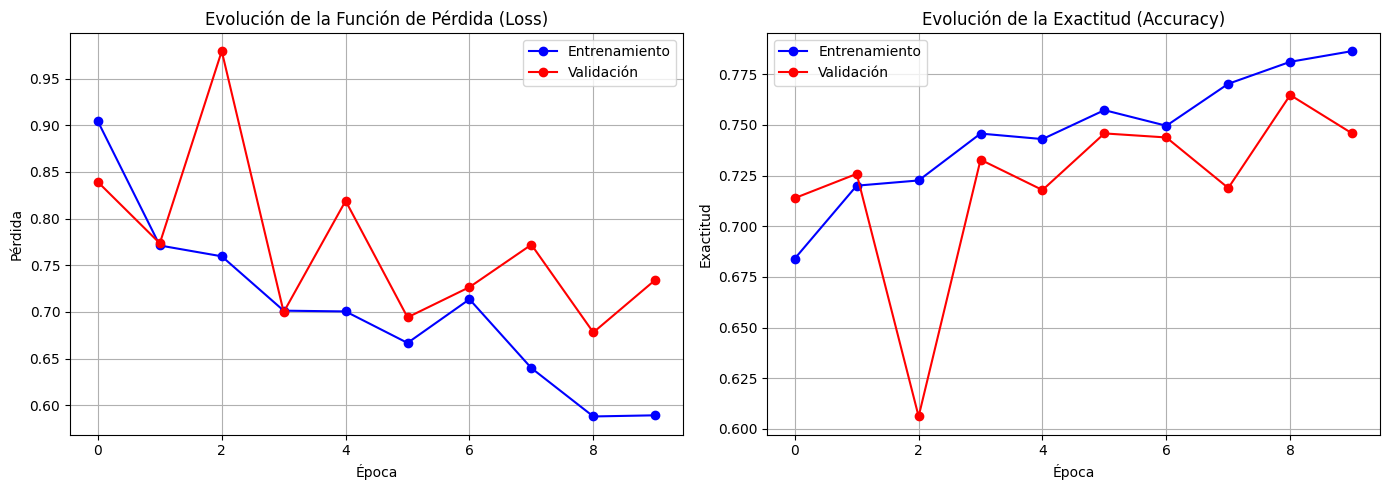

In [10]:
import time
import matplotlib.pyplot as plt

# Listas para guardar el historial y poder graficar después
historial_train_loss, historial_val_loss = [], []
historial_train_acc, historial_val_acc = [], []

num_epocas = 10 # Aumentamos un poco para que el gráfico se vea mejor

for epoca in range(num_epocas):
    inicio_tiempo = time.time()
    
    # --- FASE DE ENTRENAMIENTO ---
    modelo.train()
    train_loss, train_correctos, total_train = 0.0, 0, 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.squeeze().to(device)
        
        optimizador.zero_grad()
        outputs = modelo(inputs)
        loss = criterio(outputs, labels)
        loss.backward()
        optimizador.step()
        
        train_loss += loss.item() * inputs.size(0)
        _, predicciones = torch.max(outputs, 1)
        train_correctos += torch.sum(predicciones == labels.data)
        total_train += labels.size(0)
        
    acc_train = (train_correctos.double() / total_train).item()
    loss_train_promedio = train_loss / total_train
    
    # --- FASE DE VALIDACIÓN ---
    modelo.eval()
    val_loss, val_correctos, total_val = 0.0, 0, 0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.squeeze().to(device)
            outputs = modelo(inputs)
            loss = criterio(outputs, labels)
            
            val_loss += loss.item() * inputs.size(0)
            _, predicciones = torch.max(outputs, 1)
            val_correctos += torch.sum(predicciones == labels.data)
            total_val += labels.size(0)
            
    acc_val = (val_correctos.double() / total_val).item()
    loss_val_promedio = val_loss / total_val
    
    # Guardar en el historial
    historial_train_loss.append(loss_train_promedio)
    historial_val_loss.append(loss_val_promedio)
    historial_train_acc.append(acc_train)
    historial_val_acc.append(acc_val)
    
    tiempo_epoca = time.time() - inicio_tiempo
    print(f'Época {epoca+1}/{num_epocas} | Tiempo: {tiempo_epoca:.0f}s | Train Acc: {acc_train:.4f} | Val Acc: {acc_val:.4f}')

# ==========================================
# GENERACIÓN DEL REPORTE GRÁFICO (RÚBRICA)
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de Función de Pérdida (Loss)
ax1.plot(historial_train_loss, label='Entrenamiento', color='blue', marker='o')
ax1.plot(historial_val_loss, label='Validación', color='red', marker='o')
ax1.set_title('Evolución de la Función de Pérdida (Loss)')
ax1.set_xlabel('Época')
ax1.set_ylabel('Pérdida')
ax1.legend()
ax1.grid(True)

# Gráfico de Exactitud (Accuracy)
ax2.plot(historial_train_acc, label='Entrenamiento', color='blue', marker='o')
ax2.plot(historial_val_acc, label='Validación', color='red', marker='o')
ax2.set_title('Evolución de la Exactitud (Accuracy)')
ax2.set_xlabel('Época')
ax2.set_ylabel('Exactitud')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()